# Graficos sumo

/tmp/ipykernel_97561/1796360855.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


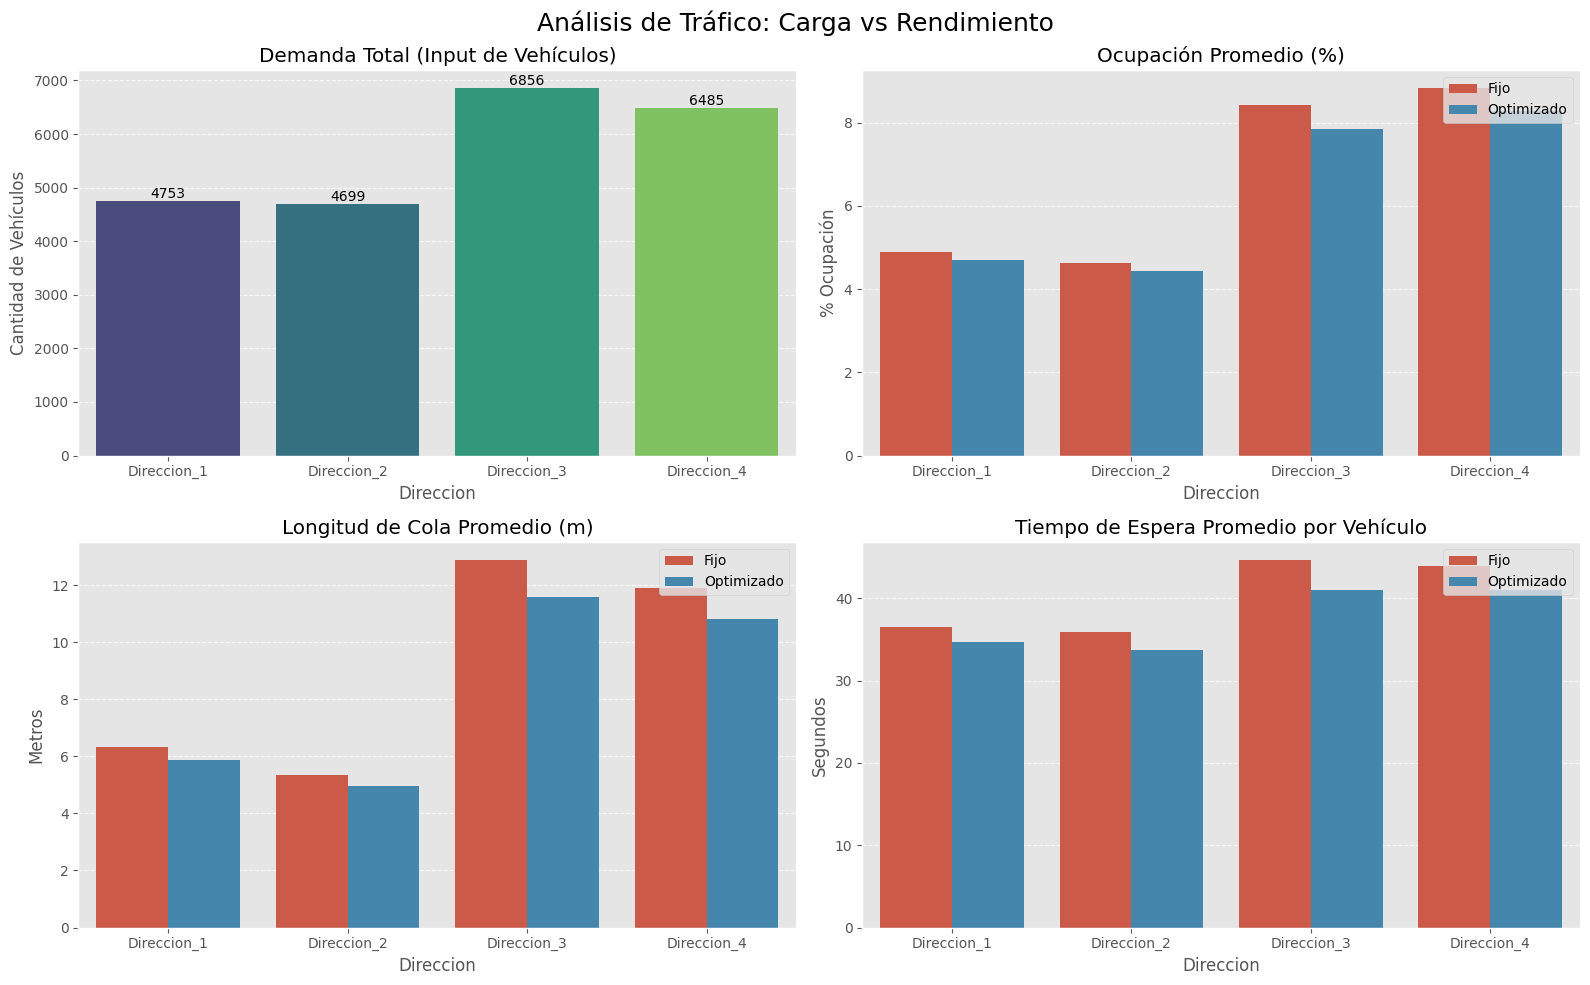

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

calles_base = {
    "Direccion_1": ["calles_sumo/ocupacion11.xml", "calles_sumo/ocupacion12.xml"],
    "Direccion_2": ["calles_sumo/ocupacion21.xml", "calles_sumo/ocupacion22.xml"],
    "Direccion_3": ["calles_sumo/ocupacion31.xml", "calles_sumo/ocupacion32.xml"],
    "Direccion_4": ["calles_sumo/ocupacion41.xml", "calles_sumo/ocupacion42.xml"],
}

calles_opt = {
    "Direccion_1": ["calles_sumo_opt/ocupacion11.xml", "calles_sumo_opt/ocupacion12.xml"],
    "Direccion_2": ["calles_sumo_opt/ocupacion21.xml", "calles_sumo_opt/ocupacion22.xml"],
    "Direccion_3": ["calles_sumo_opt/ocupacion31.xml", "calles_sumo_opt/ocupacion32.xml"],
    "Direccion_4": ["calles_sumo_opt/ocupacion41.xml", "calles_sumo_opt/ocupacion42.xml"],
}

def cargar_detector(path):
    return pd.read_xml(path, parser="etree")

def consolidar(config, etiqueta):
    data = []
    for direccion, archivos in config.items():
        dfs = []
        for a in archivos:
            try:
                dfs.append(cargar_detector(a))
            except Exception as e:
                print(f"Error cargando {a}: {e}")
                continue
        
        if dfs:
            df = pd.concat(dfs, ignore_index=True)
            df["Direccion"] = direccion
            df["Configuracion"] = etiqueta
            data.append(df)

    if not data:
        return pd.DataFrame()
    return pd.concat(data, ignore_index=True)

df_fijo = consolidar(calles_base, "Fijo")
df_opt  = consolidar(calles_opt, "Optimizado")
df_total = pd.concat([df_fijo, df_opt], ignore_index=True)

resumen = df_total.groupby(
    ["Configuracion", "Direccion"]
).agg(
    Cola_Promedio=("maxJamLengthInMeters", "mean"),
    Ocupacion_Promedio=("meanOccupancy", "mean"),
    Espera_Promedio=("meanHaltingDuration", "mean") 
).reset_index()

demanda_fija_por_direccion = {
    "Direccion_1": 4753,  
    "Direccion_2": 4699,  
    "Direccion_3": 6856,  
    "Direccion_4": 6485   
}

df_demanda = pd.DataFrame(list(demanda_fija_por_direccion.items()), columns=['Direccion', 'Total'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Análisis de Tráfico: Carga vs Rendimiento", fontsize=18)

ax_flat = axes.flatten()

sns.barplot(
    data=df_demanda, 
    x="Direccion", 
    y="Total", 
    palette="viridis", 
    ax=ax_flat[0]
)
ax_flat[0].set_title("Demanda Total (Input de Vehículos)")
ax_flat[0].set_ylabel("Cantidad de Vehículos")
for container in ax_flat[0].containers:
    ax_flat[0].bar_label(container)

sns.barplot(data=resumen, x="Direccion", y="Ocupacion_Promedio", hue="Configuracion", ax=ax_flat[1])
ax_flat[1].set_title("Ocupación Promedio (%)")
ax_flat[1].set_ylabel("% Ocupación")

sns.barplot(data=resumen, x="Direccion", y="Cola_Promedio", hue="Configuracion", ax=ax_flat[2])
ax_flat[2].set_title("Longitud de Cola Promedio (m)")
ax_flat[2].set_ylabel("Metros")

sns.barplot(data=resumen, x="Direccion", y="Espera_Promedio", hue="Configuracion", ax=ax_flat[3])
ax_flat[3].set_title("Tiempo de Espera Promedio por Vehículo")
ax_flat[3].set_ylabel("Segundos")

for i in [1, 2, 3]:
    ax_flat[i].grid(axis="y", linestyle="--", alpha=0.7)
    ax_flat[i].legend(loc='upper right')

ax_flat[0].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()